# Penguins Dataset - MLP

### [Penguins Dataset](https://seaborn.pydata.org/tutorial/introduction.html)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy pandas matplotlib seaborn scikit-learn

## Import Libraries

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
IN_FEATURES = 3
IN_FEATURES

3

In [6]:
H1 = 16
H1

16

In [7]:
H2 = 16
H2

16

In [8]:
OUT_FEATURES = 3
OUT_FEATURES

3

In [9]:
TEST_SIZE = 0.3
TEST_SIZE

0.3

In [10]:
MODE = "classification"  # "classification" or "regression"
MODE

'classification'

## Hyperparameters

In [11]:
LEARNING_RATE = 0.01
LEARNING_RATE

0.01

In [12]:
EPOCHS = 200
EPOCHS

200

In [13]:
BATCH_SIZE = 16
BATCH_SIZE

16

In [14]:
DROPOUT = 0.0
DROPOUT

0.0

## Load Dataset

In [15]:
df = pd.read_csv('data/penguins-clean.csv')

In [16]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## Clean Dataset

Map the three species to integers, keep the three continuous measurements, and standardize them so the network trains evenly.

In [17]:
SPECIES_MAP = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
df['species_id'] = df['species'].map(SPECIES_MAP)
FEATURES = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
X = df[FEATURES].to_numpy(dtype=np.float32)
y = df['species_id'].to_numpy(dtype=np.int64)
X_MEAN = X.mean(axis=0)
X_STD = X.std(axis=0)
X = (X - X_MEAN) / X_STD
X.shape, y.shape

((333, 3), (333,))

## Feature Statistical Significance (P-Values)

All three features are statistically significant. `flipper_length_mm` has the strongest separation between species.

In [18]:
f_values, p_values = f_classif(X, y)
pd.DataFrame({'feature': FEATURES,
              'f_value': f_values,
              'p_value': p_values}).sort_values('p_value')

,feature,f_value,p_value
0,bill_length_mm,397.299805,0.0
1,bill_depth_mm,344.824921,0.0
2,flipper_length_mm,567.408508,0.0


## Device

In [19]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Create Model

In [20]:
class Model(nn.Module):
    """
    A feedforward neural network with two hidden layers and optional dropout.
    """

    def __init__(self, in_features=IN_FEATURES, h1=H1, h2=H2,
                 out_features=OUT_FEATURES, dropout=DROPOUT):
        """
        Initialize the neural network layers.

        Parameters:
            in_features (int): Number of input features.
            h1 (int): Neurons in the first hidden layer.
            h2 (int): Neurons in the second hidden layer.
            out_features (int): Number of output features.
            dropout (float): Dropout rate (0.0 = no dropout).

        Returns:
            None
        """
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        """
        Run the forward pass of the network.

        Parameters:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output logits.
        """
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.out(x)

## Instantiate Model

In [21]:
torch.manual_seed(SEED)
model = Model().to(DEVICE)
model

Model(
  (fc1): Linear(in_features=3, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=3, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
)

## Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
X_train.shape, X_test.shape

((233, 3), (100, 3))

## Create Custom Dataset (Memory Efficient)

In [23]:
class NumpyDataset(torch.utils.data.Dataset):
    """
    A memory-efficient dataset that stores data as NumPy arrays.
    """

    def __init__(self, X, y, device, mode="classification"):
        """
        Initialize the dataset with NumPy arrays.

        Parameters:
            X (np.ndarray): Feature array.
            y (np.ndarray): Label array.
            device (torch.device): Device to move tensors to.
            mode (str): "classification" or "regression".

        Returns:
            None
        """
        self.X = X
        self.y = y
        self.device = device
        self.mode = mode

    def __len__(self):
        """
        Return the number of samples in the dataset.

        Parameters:
            None

        Returns:
            int: Number of samples.
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Return a single sample as tensors on the device.

        Parameters:
            idx (int): Index of the sample.

        Returns:
            tuple: Feature and label tensors.
        """
        X_tensor = torch.tensor(self.X[idx]).float().to(self.device)
        if self.mode == "classification":
            y_tensor = torch.tensor(self.y[idx]).long().to(self.device)
        else:
            y_tensor = torch.tensor(self.y[idx]).float().to(self.device)
        return X_tensor, y_tensor

## Create DataLoaders

In [24]:
train_dataset = NumpyDataset(X_train, y_train, DEVICE, MODE)
test_dataset = NumpyDataset(X_test, y_test, DEVICE, MODE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(test_loader)

(15, 7)

## Create Loss Function & Optimizer

In [25]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Train Model

### Functions

In [26]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss for the epoch.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    """
    Evaluate the model over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.
        loss_fn (nn.Module): Loss function.

    Returns:
        tuple: Mean loss and accuracy.
    """
    model.eval()
    total, correct = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            total += loss_fn(logits, y).item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total / n, correct / n

### Training Loop

In [27]:
history = {'loss': [], 'accuracy': []}
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader, loss_fn)
    history['loss'].append(test_loss)
    history['accuracy'].append(test_accuracy)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:3d} | loss {test_loss:.4f} | accuracy {test_accuracy:.4f}")

Epoch  20 | loss 0.0159 | accuracy 0.9900


Epoch  40 | loss 0.0169 | accuracy 0.9900


Epoch  60 | loss 0.0232 | accuracy 0.9900


Epoch  80 | loss 0.0270 | accuracy 0.9900


Epoch 100 | loss 0.0295 | accuracy 0.9900


Epoch 120 | loss 0.0228 | accuracy 0.9900


Epoch 140 | loss 0.0357 | accuracy 0.9900


Epoch 160 | loss 0.0464 | accuracy 0.9900


Epoch 180 | loss 0.0495 | accuracy 0.9900


Epoch 200 | loss 0.0619 | accuracy 0.9900


### Visualize Training

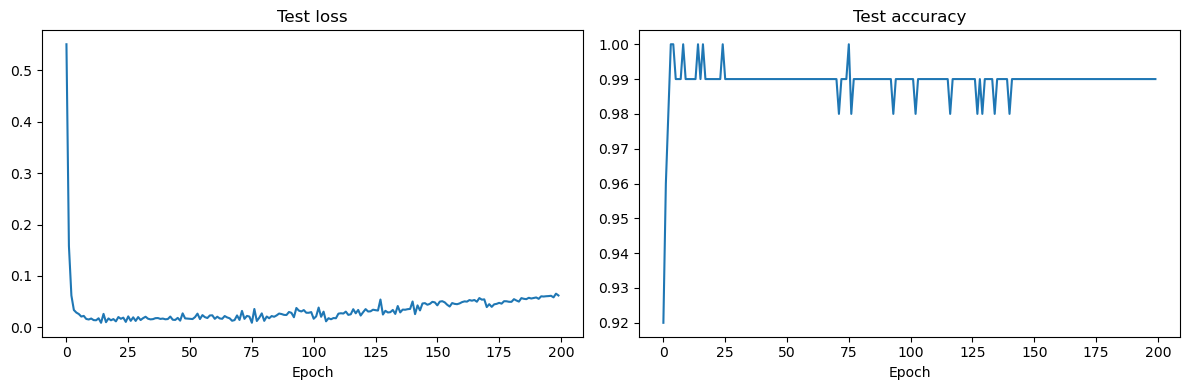

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['loss'])
axes[0].set_title('Test loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(history['accuracy'])
axes[1].set_title('Test accuracy')
axes[1].set_xlabel('Epoch')
fig.tight_layout()
plt.show()

## Evaluate Model

In [29]:
_, accuracy = evaluate(model, test_loader, loss_fn)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9900


In [30]:
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        all_preds.append(model(x).argmax(1).cpu().numpy())
        all_labels.append(y.cpu().numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=list(SPECIES_MAP)))

[[43  1  0]
 [ 0 20  0]
 [ 0  0 36]]
              precision    recall  f1-score   support

      Adelie       1.00      0.98      0.99        44
   Chinstrap       0.95      1.00      0.98        20
      Gentoo       1.00      1.00      1.00        36

    accuracy                           0.99       100
   macro avg       0.98      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



## Save Model

In [31]:
torch.save(model.state_dict(), 'models/mlp_penguins.pt')
print('saved mlp_penguins.pt')

saved mlp_penguins.pt


## Load Model

In [32]:
loaded_model = Model().to(DEVICE)
loaded_model.load_state_dict(torch.load('models/mlp_penguins.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded mlp_penguins.pt')

loaded mlp_penguins.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_76916/2132460299.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('mode

## Inference

### Function

In [33]:
def predict(model, features):
    """
    Predict the species for one standardized measurement.

    Parameters:
        model (nn.Module): Trained model.
        features (list): Raw bill length, bill depth, and flipper length.

    Returns:
        tuple: Predicted species name and confidence.
    """
    model.eval()
    scaled = (np.array(features, dtype=np.float32) - X_MEAN) / X_STD
    with torch.no_grad():
        X_new = torch.tensor(scaled).float().to(DEVICE).unsqueeze(0)
        probs = torch.softmax(model(X_new), dim=1)
        confidence, predicted = probs.max(dim=1)
    return list(SPECIES_MAP)[predicted.item()], confidence.item()

### Run Inference

In [34]:
species, confidence = predict(loaded_model, [47.5, 15.0, 217.0])
print(f"Predicted species: {species} ({confidence:.4f})")

Predicted species: Gentoo (1.0000)
